# 1. Convert list to csv

In [1]:
HEADER = [
    'id', 'order', 'year', 'country', 
    'study_focus', 'historical_site_type', 'historical_site_type_sub', 
    'platform', 'device', 'technique', 'technique_sub', 
    'software_data', 'software_modeling', 'software_render',
    'elo', 'cluster'
]

ROWS = [
    # id, 0_order, 1_year, 2_country, 3_study_focus, 4_historical_site_type, 5_historical_site_type_sub, 6_platform, 7_device, 8_technique, 9_technique_sub, 10_software_data, 11_software_modeling, 12_software_render
    (1, "001", 2015, "South Korea", "Visualization", "Building", "Religious", ["VR"], ["HMD"], ["3D Scanning", "Modeling & Reconstruction"], ["Laser Scanning", "3D Modeling"], ["Australis Photometric"], ["Autodesk 3ds Max"], ["Unity"]),
    (2, "002", 2015, "Spain", "Reconstruction", "Archaeological Site", "LandBased", ["AR"], ["Mobile"], ["Image-Based Techniques", "Modeling & Reconstruction"], ["Photogrammetry", "Structure from Motion (SfM)", "3D Modeling"], ["Agisoft Metashape"], ["Blender"], [""]),
    (3, "003", 2015, "Peru", "Visualization", "Archaeological Site", "LandBased", ["AR"], ["Mobile"], ["Image-Based Techniques"], ["Photogrammetry", "Structure from Motion (SfM)"], ["Agisoft Metashape"], [""], [""]),
    (4, "004", 2015, "Greece", "Reconstruction", "Archaeological Site", "LandBased", ["AR", "MR"], ["HMD", "Mobile"], ["Image-Based Techniques", "Geospatial Techniques"], ["Photogrammetry", "Structure from Motion (SfM)", "Geographic Information System (GIS)"], ["Agisoft Metashape"], ["Blender", "Autodesk 3ds Max"], ["Unity"]),
    (5, "005", 2015, "Italy", "Reconstruction", "Archaeological Site", "LandBased", ["VR"], ["HMD", "Mobile"], ["Image-Based Techniques", "Geospatial Techniques", "Modeling & Reconstruction"], ["Photogrammetry", "Geographic Information System (GIS)", "3D Modeling"], ["QGIS"], ["Autodesk Maya"], ["Unity"]),
    (6, "006", 2016, "Italy", "Visualization", "Archaeological Site", "LandBased", ["AR"], ["Mobile"], ["Image-Based Techniques"], ["Photogrammetry"], ["ArcGIS"], ["Blender"], ["Unity"]),
    (7, "007", 2016, "Indonesia", "Visualization", "Archaeological Site", "LandBased", ["AR"], ["HMD"], ["Image-Based Techniques"], ["Photogrammetry"], ["Agisoft Metashape"], ["Autodesk Remake"], ["Unity"]),
    (8, "008", 2016, "Peru", "Visualization", "Archaeological Site", "LandBased", ["AR"], ["Mobile"], ["Image-Based Techniques"], ["Photogrammetry"], [""], [""], [""]),
    (9, "009", 2016, "Romania", "Visualization", "Artistic Feature", "Artifact", ["VR", "AR"], ["HMD", "Mobile"], ["3D Scanning", "Image-Based Techniques", "Modeling & Reconstruction"], ["Laser Scanning", "Photogrammetry", "3D Modeling"], [""], [""], ["Unity"]),
    (10, "010", 2017, "Cyprus", "Visualization", "Archaeological Site", "LandBased", ["VR"], ["HMD"], ["Image-Based Techniques", "Modeling & Reconstruction"], ["Photogrammetry", "3D Modeling"], ["Agisoft Metashape"], [""], ["Unity"]),
    (11, "011", 2017, "Saudi Arabia", "Visualization", "Archaeological Site", "LandBased", ["VR"], ["HMD"], ["3D Scanning", "Image-Based Techniques", "Modeling & Reconstruction"], ["Laser Scanning", "Photogrammetry", "Structure from Motion (SfM)", "3D Modeling"], [""], ["Autodesk Revit"], ["Unity"]),
    (12, "012", 2017, "China", "Visualization", "Building", "Fortification", ["VR"], ["HMD", "PC", "Mobile"], ["3D Scanning", "Image-Based Techniques", "Modeling & Reconstruction"], ["Laser Scanning", "Photogrammetry", "3D Modeling"], ["Agisoft Metashape", "Reality Capture"], ["Blender", "Rhinoceros"], ["Unreal Engine", "ARKit"]),
    (13, "013", 2017, "Spain", "Restoration", "Artistic Feature", "Artifact", ["VR"], ["Mobile"], ["3D Scanning", "Image-Based Techniques"], ["Laser Scanning", "Photogrammetry"], ["Autodesk ReCap", "Agisoft Metashape"], ["Blender", "Rhinoceros"], ["Unity"]),
    (14, "014", 2017, "Italy", "Reconstruction", "Building", "Religious", ["VR", "AR"], ["HMD", "Mobile"], ["Image-Based Techniques"], ["Photogrammetry"], ["Agisoft Metashape"], ["Blender"], [""]),
    (15, "015", 2017, "Turkiye", "Reconstruction", "Archaeological Site", "LandBased", ["VR", "AR"], ["HMD", "Immersive Display"], ["3D Scanning", "Image-Based Techniques"], ["Laser Scanning", "Photogrammetry", "Structure from Motion (SfM)"], ["Agisoft Metashape"], [""], [""]),
]

PATH_DATA = 'data/DATA_.csv'

In [2]:
STUDY_FOCUS_MAP = {
    'sf_restoration'    : 'Restoration',
    'sf_visualization'  : 'Visualization',
    'sf_reconstruction' : 'Reconstruction',
}

HISTORICAL_SITE_TYPE_MAP = {
    'hst_archaeological_site' : 'Archaeological Site',
    'hst_artistic_feature'    : 'Artistic Feature',
    'hst_building'            : 'Building',
    'hst_natural_space'       : 'Natural Space',
}

HISTORICAL_SITE_TYPE_SUB_MAP = {
    # Archaeological Site
    'hst_sub_landbased'  : 'LandBased',
    'hst_sub_underwater' : 'Underwater',
    
    # Artistic Feature
    'hst_sub_architectural_asset' : 'ArchitecturalAsset',
    'hst_sub_artifact'            : 'Artifact',
    
    # Building
    'hst_sub_fortification' : 'Fortification',
    'hst_sub_religious'     : 'Religious',
    'hst_sub_urbanspace'    : 'UrbanSpace',
    
    # Natural Space
    'hst_sub_cave' : 'Cave',
}

PLATFORM_MAP = {
    'platform_vr' : 'VR',
    'platform_ar' : 'AR',
    'platform_mr' : 'MR',
    'platform_xr' : 'XR',
}

DEVICE_MAP = {
    'device_hmd'               : 'HMD',
    'device_pc'                : 'PC',
    'device_mobile'            : 'Mobile',
    'device_immersive_display' : 'Immersive Display',
}

TECHNIQUE_MAP = {
    'tech_3d_scanning'     : '3D Scanning',
    'tech_image_based'     : 'Image-Based Techniques',
    'tech_geospatial'      : 'Geospatial Techniques',
    'tech_modeling'        : 'Modeling & Reconstruction',
    'tech_data_processing' : 'Data Processing'
}

TECHNIQUE_SUB_MAP = {
    # 3D Scanning
    'tech_sub_laser_scanning'                  : 'Laser Scanning',
    'tech_sub_rgbd_imaging'                    : 'RGB-D Imaging',
    'tech_sub_volumetric_capture'              : 'Real-Time Volumetric Capture',
    
    # Image-Based Techniques
    'tech_sub_photogrammetry'                  : 'Photogrammetry',
    'tech_sub_spherical'                       : 'Spherical Imaging',
    'tech_sub_ibm'                             : 'Image-Based Modeling (IBM)',
    'tech_sub_sfm'                             : 'Structure from Motion (SfM)',
    'tech_sub_uav'                             : 'UAV Aerial Imaging',
    'tech_sub_mvs'                             : 'Multi-View Stereo (MVS)',
    
    # Geospatial Techniques
    'tech_sub_gis'                             : 'Geographic Information System (GIS)',
    'tech_sub_gnss'                            : 'Global Navigation Satellite System (GNSS)',
    'tech_sub_dem'                             : 'Digital Elevation Models (DEM)',
    'tech_sub_slam'                            : 'Visual-Inertial SLAM',
    'tech_sub_beacon_localization'             : 'Beacon Localization',
    
    # Modeling & Reconstruction
    'tech_sub_3d'                              : '3D Modeling',
    'tech_sub_bim'                             : 'BIM',
    'tech_sub_hbim'                            : 'HBIM',
    'tech_sub_sm'                              : 'Stratigraphic Mapping',
    'tech_sub_anastylosis'                     : 'Virtual Anastylosis',
    'tech_sub_adi'                             : 'Archaeological Data Integration',
    
    # Data Processing
    'tech_sub_semantic_data_extraction'        : 'Semantic Data Extraction',
    'tech_sub_3d_texturing'                    : '3D Texturing',
    'tech_sub_texture_mapping'                 : 'Texture Mapping',
    'tech_sub_rbm'                             : 'Range-Based Modeling (RBM)',
    'tech_sub_hdr_imaging'                     : 'HDR Imaging',
    'tech_sub_archaeological_interpretation'   : 'Archaeological Interpretation',
}

SOFTWARE_DATA_MAP = {
    'sd_autodesk_recap'        : 'Autodesk ReCap',
    'sd_autodesk_mudbox'       : 'Autodesk Mudbox',
    'sd_autodesk_meshmixer'    : 'Autodesk Meshmixer',
    'sd_agisoft_metashape'     : 'Agisoft Metashape',
    'sd_trimble_business'      : 'Trimble Business Center',
    'sd_trimble_realworks'     : 'Trimble RealWorks',
    'sd_reality_capture'       : 'Reality Capture',
    'sd_context_capture'       : 'ContextCapture',
    'sd_cloudcompare'          : 'CloudCompare',
    'sd_pix4d_capture'         : 'PIX4D Capture',
    'sd_leica_cyclone'         : 'Leica Cyclone',
    'sd_dstretch'              : 'Dstretch',
    'sd_arcgis'                : 'ArcGIS',
    'sd_faro_scene'            : 'Faro Scene',
    'sd_focus_scene'           : 'Focus Scene',
    'sd_processing'            : 'Processing',
    'sd_australis_photometric' : 'Australis Photometric',
    'sd_affinity'              : 'Affinity',
    'sd_polycam'               : 'Polycam',
    'sd_graphos'               : 'GRAPHOS',
    'sd_catia'                 : 'CATIA',
    'sd_qgis'                  : 'QGIS',
    'sd_mysql'                 : 'MySQL',
    'sd_world_creator_2'       : 'World Creator 2',
    'sd_mesh_buildup_wizard'   : 'Mesh Buildup Wizard',
    'sd_riegl_riscan'          : 'Riegl RiScan',
    'sd_3df_zephyr'            : '3DF Zephyr',
    'sd_arcmap'                : 'ArcMap',
    'sd_dynamo'                : 'Dynamo',
    'sd_ptgui'                 : 'PTGui',
    'sd_matlab'                : 'MATLAB',
    'sd_mongodb'               : 'MongoDB',
    'sd_postgis'               : 'PostGIS',
    'sd_postgresql'            : 'PostgreSQL',
}

SOFTWARE_MODELING_MAP = {
    'sm_autodesk_autocad' : 'Autodesk AutoCAD',
    'sm_autodesk_3ds_max' : 'Autodesk 3ds Max',
    'sm_autodesk_maya'    : 'Autodesk Maya',
    'sm_autodesk_revit'   : 'Autodesk Revit',
    'sm_autodesk_remake'  : 'Autodesk Remake',
    'sm_autodesk_fusion'  : 'Autodesk Fusion 360',
    'sm_archicad'         : 'ArchiCAD',
    'sm_blender'          : 'Blender',
    'sm_sketchup'         : 'SketchUp',
    'sm_rhinoceros'       : 'Rhinoceros',
    'sm_maxon_cinema4d'   : 'Maxon Cinema4D',
    'sm_zbrush'           : 'ZBrush',
    'sm_meshlab'          : 'Meshlab',
    'sm_meshmixer'        : 'Meshmixer',
    'sm_ramsete'          : 'Ramsete',
    'sm_simlab'           : 'SIMLAB',
    'sm_3dreshaper'       : '3DReshaper',
    'sm_fuenta_nueva'     : 'Fuente Nueva',
    'sm_geomagic'         : 'Geomagic',
}

SOFTWARE_RENDER_MAP = {
    'sr_unity'            : 'Unity',
    'sr_unreal_engine'    : 'Unreal Engine',
    'sr_vray'             : 'V-Ray',
    'sr_lumion'           : 'Lumion',
    'sr_enscape'          : 'Enscape',
    'sr_twinmotion'       : 'Twinmotion',
    'sr_sketchfab'        : 'Sketchfab',
    'sr_maxwhere'         : 'MaxWhere',
    'sr_vuforia'          : 'Vuforia',
    'sr_gimp'             : 'Gimp',
    'sr_easyar'           : 'EasyAR',
    'sr_pano2vr'          : 'Pano2VR',
    'sr_augment'          : 'Augment',
    'sr_three_js'         : 'Three.js',
    'sr_middlevr'         : 'MiddleVR',
    'sr_renderman'        : 'RenderMan',
    'sr_shapespark'       : 'Shapespark',
    'sr_fb360_encoder'    : 'FB360 Encoder',
    'sr_kolor_panotour'   : 'Kolor Panotour',
    'sr_arkit'            : 'ARKit',
    'sr_verge3d'          : 'Verge3D',
    'sr_d5_render'        : 'D5 Render',
}

COLUMNS_METADATA = {
    'study_focus'              : (STUDY_FOCUS_MAP,              False),
    'historical_site_type'     : (HISTORICAL_SITE_TYPE_MAP,     False),
    'historical_site_type_sub' : (HISTORICAL_SITE_TYPE_SUB_MAP, False),
    'platform'                 : (PLATFORM_MAP,                 True),
    'device'                   : (DEVICE_MAP,                   True),
    'technique'                : (TECHNIQUE_MAP,                True),
    'technique_sub'            : (TECHNIQUE_SUB_MAP,            True),
    'software_data'            : (SOFTWARE_DATA_MAP,            True),
    'software_modeling'        : (SOFTWARE_MODELING_MAP,        True),
    'software_render'          : (SOFTWARE_RENDER_MAP,          True),
}

In [3]:
import pandas as pd
import json


def convert_list_csv(header, rows):
    serialized_rows = [[_serialize(cell) for cell in row] for row in rows]
    return pd.DataFrame(serialized_rows, columns=header)


def save_csv(df, path_output, k=None):
    filename = f"{path_output}_{k}.csv" if k is not None else path_output
    df.to_csv(filename, index=False, encoding="utf-8")


def read_csv(path_input, columns_metadata=None):
    df = pd.read_csv(path_input)

    if columns_metadata:
        for column, (_, is_list) in columns_metadata.items():
            if is_list and column in df.columns:
                df[column] = df[column].fillna("[]").apply(_parse)
    return df


def _serialize(cell):
    return json.dumps(cell, ensure_ascii=False) if isinstance(cell, list) else cell


def _parse(cell):
    try:
        data = json.loads(cell)
        return data if isinstance(data, list) else []
    except json.JSONDecodeError:
        return []

In [4]:
def check_anomaly(df, columns_metadata):
    anomalies = {}
    list_cols = [col for col, (_, is_list) in columns_metadata.items() if is_list]

    for col in list_cols:
        if col not in df.columns:
            anomalies[col] = ["[Missing column]"]
            continue

        valid_values = set(columns_metadata[col][0].values())
        found = {item for row in df[col] for item in row}
        unexpected = sorted(found - valid_values)
        if unexpected:
            anomalies[col] = unexpected

    return anomalies

In [5]:
def print_summary(df, columns_metadata):
    print(f"\n\n\n================== {"Summary of the Dataset"} ==================", end="")
    header = ["category", "count", "percent"]

    total = len(df)
    for column, (mapping, is_list) in columns_metadata.items():
        rows = []

        if column in df.columns:
            for label in mapping.values():
                count = df[column].apply(lambda x: label in x).sum() if is_list else (df[column] == label).sum()
                rows.append((label, count, round(count / total * 100, 2)))
        else:
            for column_binary in mapping:
                if column_binary in df.columns:
                    count = df[column_binary].sum()
                    rows.append((column_binary, count, round(count / total * 100, 2)))

        if rows:
            _print_table(column, header, rows)


def print_anomaly(df, columns_metadata):
    print(f"\n\n\n================== {"Config vs Data Features"} ==================", end="")
    header = ["issue"]
    anomalies = check_anomaly(df, columns_metadata)
    
    if not anomalies:
        print("\nNO ANOMALIES\n")
        return

    for column, features in anomalies.items():
        rows = [[feature] for feature in features]
        _print_table(column, header, rows)


def _print_table(title, header, rows):
    col_widths = _compute_column_width(header, rows)
    header_line = " | ".join(header[i].ljust(col_widths[i]) for i in range(len(header)))
    
    print(f"\n{title}")
    print(header_line)
    print("─" * len(header_line))
    for row in rows:
        line = " | ".join(str(cell).ljust(col_widths[i]) for i, cell in enumerate(row))
        print(line)


def _compute_column_width(headers, rows):
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))
    return [w + 2 for w in widths]

In [6]:
df = convert_list_csv(HEADER[:-2], ROWS)
save_csv(df, PATH_DATA)

print_summary(read_csv(PATH_DATA, COLUMNS_METADATA), COLUMNS_METADATA)
print_anomaly(read_csv(PATH_DATA, COLUMNS_METADATA), COLUMNS_METADATA)




================== Summary of the Dataset ==================
study_focus
category         | count   | percent  
──────────────────────────────────────
Restoration      | 1       | 6.67     
Visualization    | 9       | 60.0     
Reconstruction   | 5       | 33.33    

historical_site_type
category              | count   | percent  
───────────────────────────────────────────
Archaeological Site   | 5       | 33.33    
Artistic Feature      | 1       | 6.67     
Building              | 7       | 46.67    
Natural Space         | 2       | 13.33    

historical_site_type_sub
category             | count   | percent  
──────────────────────────────────────────
LandBased            | 5       | 33.33    
Underwater           | 0       | 0.0      
ArchitecturalAsset   | 0       | 0.0      
Artifact             | 1       | 6.67     
Fortification        | 3       | 20.0     
Religious            | 3       | 20.0     
UrbanSpace           | 1       | 6.67     
Cave                 | 2      

# 2. One-hot encoding

In [7]:
MIN_FREQ = 10

PATH_DATA_BINARY = 'data/DATA_BINARY.csv'

In [8]:
def create_df_binary(df, columns_metadata):
    for column, (mapping, is_list) in columns_metadata.items():
        if column in df.columns:
            df = _create_rows_onehot(df, column, mapping, is_list)

    ordered_cols = []
    for column, (mapping, _) in columns_metadata.items():
        ordered_cols.extend([flag for flag in mapping.keys() if flag in df.columns])

    return df[ordered_cols]


def filter_rare_features(df, columns_metadata, min_freq):
    for base, (mapping_dict, is_list) in columns_metadata.items():
        if not is_list:
            continue

        for col in mapping_dict.keys():
            if col in df.columns and df[col].sum() < min_freq:
                df.drop(columns=[col], inplace=True)

    return df


def _create_rows_onehot(df, column, mapping, is_list=True):
    flags = {}
    for column_flag, label in mapping.items():
        if is_list:
            flags[column_flag] = df[column].apply(lambda lst: int(label in lst))
        else:
            flags[column_flag] = df[column].apply(lambda x: int(x == label))
    return pd.concat([df, pd.DataFrame(flags, index=df.index)], axis=1)

In [9]:
df_binary = create_df_binary(read_csv(PATH_DATA, COLUMNS_METADATA), COLUMNS_METADATA)
df_rares  = filter_rare_features(df_binary, COLUMNS_METADATA, MIN_FREQ)
save_csv(df_rares, PATH_DATA_BINARY)

print_summary(read_csv(PATH_DATA_BINARY), COLUMNS_METADATA)




================== Summary of the Dataset ==================
study_focus
category            | count   | percent  
─────────────────────────────────────────
sf_restoration      | 1       | 6.67     
sf_visualization    | 9       | 60.0     
sf_reconstruction   | 5       | 33.33    

historical_site_type
category                  | count   | percent  
───────────────────────────────────────────────
hst_archaeological_site   | 5       | 33.33    
hst_artistic_feature      | 1       | 6.67     
hst_building              | 7       | 46.67    
hst_natural_space         | 2       | 13.33    

historical_site_type_sub
category                      | count   | percent  
───────────────────────────────────────────────────
hst_sub_landbased             | 5       | 33.33    
hst_sub_underwater            | 0       | 0.0      
hst_sub_architectural_asset   | 0       | 0.0      
hst_sub_artifact              | 1       | 6.67     
hst_sub_fortification         | 3       | 20.0     
hst_sub_religi

# 3. Calculate k-mean

In [13]:
ELOS = [
    1526, 1448, 1637, 1568, 1210, 
    1281, 1557, 1505, 1716, 1670,
    1552, 1294, 1414, 1407, 1691,
]

K_MAX = 10
RANDOM_STATE = 42

PATH_PLOT = 'data/K_MEAN.png'

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


def plot_k_means(elos, k_max, random_state):
    X = np.array(elos).reshape(-1, 1)
    k_values = list(range(1, k_max))

    inertias = []
    for k in k_values:
        k_mean = KMeans(n_clusters=k, random_state=random_state).fit(X)
        inertias.append(k_mean.inertia_)

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, inertias, marker="o")
    plt.xticks(k_values)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for Optimal Number of Clusters")

    return plt

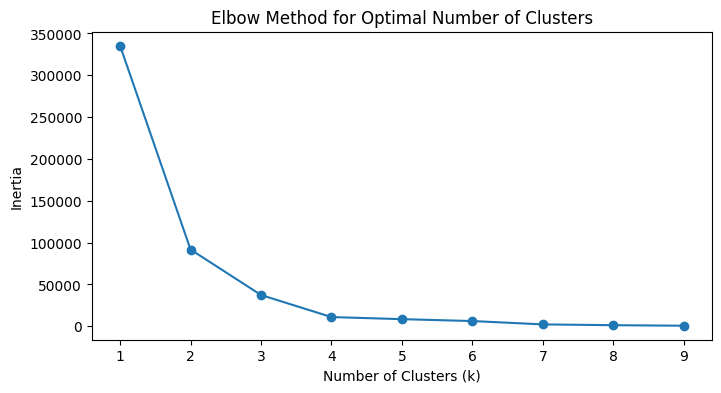

In [17]:
plt = plot_k_means(ELOS, K_MAX, RANDOM_STATE)

plt.savefig(PATH_PLOT)
plt.show()

# 4. Clustering

In [18]:
K = 3

PATH_DATA_CLUSTER = 'data/DATA_CLUSTER.csv'

In [19]:
def create_df_cluster(df, elos, k_values, random_state):
    df = _add_column_elo(df, elos)

    if isinstance(k_values, int):
        return _add_column_cluster(df, k_values, random_state)

    df_clustered = {}
    for k in k_values:
        df_clustered[k] = _add_column_cluster(df, k, random_state)
    return df_clustered


def _add_column_elo(df, elos):
    if len(df) != len(elos):
        raise ValueError(f"len(ROWS) {len(df)} != len(ELOS) {len(elos)}")

    df = df.copy()
    df["elo"] = elos
    return df


def _add_column_cluster(df, k, random_state):
    km = _get_k_means(k, random_state)
    km.fit(df[["elo"]])
    labels = km.labels_

    centers = km.cluster_centers_.flatten()
    order = centers.argsort()
    remap = {original: new + 1 for new, original in enumerate(order)}

    df = df.copy()
    df["cluster"] = [f"cluster_{remap[label]}" for label in labels]
    return df


def _get_k_means(k, random_state):
    return KMeans(n_clusters=k, random_state=random_state)

In [20]:
def print_cluster_range(df, k=None):
    print(f"\n\n\n================== {f"cluster{k or ''}"} ==================", end="")
    print()

    summary = df.groupby('cluster')['elo'].agg(['min', 'max', 'count'])
    for cluster, row in summary.iterrows():
        print(f"{cluster}: min={row['min']} | max={row['max']} | {row['count']} items")

In [21]:
df_cluster = create_df_cluster(read_csv(PATH_DATA_BINARY), ELOS, K, RANDOM_STATE)
save_csv(df_cluster, PATH_DATA_CLUSTER)

print_summary(read_csv(PATH_DATA_CLUSTER), COLUMNS_METADATA)
print_cluster_range(read_csv(PATH_DATA_CLUSTER))




================== Summary of the Dataset ==================
study_focus
category            | count   | percent  
─────────────────────────────────────────
sf_restoration      | 1       | 6.67     
sf_visualization    | 9       | 60.0     
sf_reconstruction   | 5       | 33.33    

historical_site_type
category                  | count   | percent  
───────────────────────────────────────────────
hst_archaeological_site   | 5       | 33.33    
hst_artistic_feature      | 1       | 6.67     
hst_building              | 7       | 46.67    
hst_natural_space         | 2       | 13.33    

historical_site_type_sub
category                      | count   | percent  
───────────────────────────────────────────────────
hst_sub_landbased             | 5       | 33.33    
hst_sub_underwater            | 0       | 0.0      
hst_sub_architectural_asset   | 0       | 0.0      
hst_sub_artifact              | 1       | 6.67     
hst_sub_fortification         | 3       | 20.0     
hst_sub_religi

# 5. Split dataset

In [22]:
TEST_SIZE    = 0.2
RANDOM_STATE = 42

In [23]:
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split


def split_dataset(df, test_size, random_state, column_drop, column_label):
    X = df.drop(column_drop, axis=1)
    y = LabelEncoder().fit_transform(df[column_label])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )
    return X_train, X_test, y_train, y_test

In [24]:
X_train, X_test, y_train, y_test = split_dataset(
    df           = read_csv(PATH_DATA_CLUSTER), 
    test_size    = TEST_SIZE, 
    random_state = RANDOM_STATE, 
    column_drop  = ['elo', 'cluster'], 
    column_label = 'cluster'
)

# 6. Calculate for features

## 6.1. Compute features score

In [25]:
PATH_DATA_FEATURES_SCORES = 'data/DATA_FEATURES_SCORES.csv'

In [26]:
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif


def compute_feature_scores(X_train, y_train):
    pipe = Pipeline([
        ('var', VarianceThreshold()),
        ('skb', SelectKBest(f_classif, k='all'))
    ])
    pipe.fit(X_train, y_train)

    mask  = pipe.named_steps['var'].get_support()
    feats = X_train.columns[mask]
    skb   = pipe.named_steps['skb']

    rows = []
    for feat, f, p in zip(feats, skb.scores_, skb.pvalues_):
        rows.append({
            'feature':   feat,
            'f_score':    f,
            'p_value':    p,
            'frequency':  int(X_train[feat].sum()),
        })

    return pd.DataFrame(rows)

In [27]:
def print_scores(df, columns, sort_by=None, threshold_f=None, threshold_p=None, threshold_freq=None, top_n=None):    
    print(f"\n\n\n================== {f"Top items sort by {sort_by}" if top_n else "All features"} ==================", end="")
    
    if sort_by:
        df = df.sort_values(by=sort_by, ascending=False)
        
    if threshold_f:
        column_f = columns[1]
        df = df[df[column_f] >= threshold_f]

    if threshold_p:
        column_filter = columns[2]
        df = df[df[column_filter] <= threshold_p]

    if threshold_freq:
        column_freq = columns[3]
        df = df[df[column_freq] >= threshold_freq]

    if top_n:
        df = df.head(top_n)

    rows = _get_rows_score(df, columns)
    _print_table("", columns, rows)


def _get_rows_score(df, columns):
    rows = []
    for _, row in df.iterrows():
        formatted = []
        for col in columns:
            val = row[col]
            if isinstance(val, float):
                formatted.append(f"{val:.2f}")
            else:
                formatted.append(str(val))
        rows.append(tuple(formatted))
    return rows

In [28]:
df_rank_scores = compute_feature_scores(X_train, y_train)
save_csv(df_rank_scores, PATH_DATA_FEATURES_SCORES)

print_scores(
    df             = read_csv(PATH_DATA_FEATURES_SCORES), 
    columns        = ['feature', 'f_score', 'p_value', 'frequency'],
    sort_by        = None,
    threshold_f    = 1,
    threshold_p    = None,
    threshold_freq = None,
    top_n          = None,
)




================== All features ==================

feature                 | f_score   | p_value   | frequency  
─────────────────────────────────────────────────────────────
hst_artistic_feature    | 3.75      | 0.07      | 1          
hst_building            | 1.01      | 0.40      | 5          
hst_sub_artifact        | 3.75      | 0.07      | 1          
hst_sub_fortification   | 1.41      | 0.29      | 3          
platform_vr             | 7.31      | 0.01      | 9          
device_hmd              | 1.03      | 0.40      | 10         


## 6.2. Filter features columns

In [29]:
PATH_DATA_FEATURES_FILTER = 'data/DATA_FEATURES_FILTER.csv'

In [30]:
def keep_columns_csv(df, columns_metadata, column_keep):
    keep = []
    for key in column_keep:
        if key in df.columns:
            keep.append(key)
        if key in columns_metadata:
            mapping, _ = columns_metadata[key]
            for column in mapping:
                if column in df.columns:
                    keep.append(column)

    keep = list(dict.fromkeys(keep))
    return df[keep]

In [31]:
column_keep_features = [
    'sf_visualization', 
    'sf_reconstruction', 
    'hst_sub_architectural_asset', 
    'hst_sub_artifact',
    'hst_sub_fortification',
    'platform_vr',
    'platform_ar',
    'device_hmd',
    'device_pc',
    'tech_image_based',
    'tech_geospatial',
    'tech_sub_photogrammetry',
    'tech_sub_sfm',
    'sd_agisoft_metashape',
    'sd_leica_cyclone',
    'sm_autodesk_3ds_max',
    'sr_unity',
] + [
    'elo',
    'cluster',
]
df_filter = keep_columns_csv(read_csv(PATH_DATA_CLUSTER), COLUMNS_METADATA, column_keep_features)
save_csv(df_filter, PATH_DATA_FEATURES_FILTER)

print_summary(read_csv(PATH_DATA_FEATURES_FILTER), COLUMNS_METADATA)




================== Summary of the Dataset ==================
study_focus
category            | count   | percent  
─────────────────────────────────────────
sf_visualization    | 9       | 60.0     
sf_reconstruction   | 5       | 33.33    

historical_site_type_sub
category                      | count   | percent  
───────────────────────────────────────────────────
hst_sub_architectural_asset   | 0       | 0.0      
hst_sub_artifact              | 1       | 6.67     
hst_sub_fortification         | 3       | 20.0     

platform
category      | count   | percent  
───────────────────────────────────
platform_vr   | 12      | 80.0     

device
category     | count   | percent  
──────────────────────────────────
device_hmd   | 12      | 80.0     

technique
category           | count   | percent  
────────────────────────────────────────
tech_image_based   | 13      | 86.67    

technique_sub
category                  | count   | percent  
──────────────────────────────────────────

## 6.3. Run models for features

In [32]:
PATH_DATA_FEATURES_RESULT = 'data/DATA_FEATURES_RESULT.csv'

In [33]:
from sklearn.naive_bayes       import GaussianNB
from sklearn.linear_model      import LogisticRegression
from sklearn.neural_network    import MLPClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier

from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler

import time


MODELS = [
    ('Naive Bayes (Gaussian)'                  , GaussianNB()),
    ('Logistic Regression (ridge)'             , LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
    ('Deep Neural Network (two hidden layers)' , MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)),
    ('Decision Tree (CART)'                    , DecisionTreeClassifier(random_state=42)),
    ('Random Forest (100 trees)'               , RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Support Vector Machine (RBF Kernel)'     , SVC(kernel='rbf', random_state=42)),
    ('k-Nearest Neighbors'                     , KNeighborsClassifier()),
]


def evaluate_models(X_train, X_test, y_train, y_test):
    results = []
    for name, model in MODELS:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    model),
        ])
        start = time.time()
        pipe.fit(X_train, y_train)
        accuracy = pipe.score(X_test, y_test) * 100
        elapsed  = time.time() - start
        results.append((name, accuracy, elapsed))

    return results

In [34]:
def print_models(df, columns, sort_by=None):
    print(f"\n\n\n================== {"Model Evaluation Results"} ==================", end="")

    if sort_by:
        df = df.sort_values(by=sort_by, ascending=False)

    rows = _get_rows_score(df, columns)
    _print_table("", columns, rows)

In [35]:
X_train, X_test, y_train, y_test = split_dataset(
    df           = read_csv(PATH_DATA_FEATURES_FILTER), 
    test_size    = TEST_SIZE, 
    random_state = RANDOM_STATE, 
    column_drop  = ['elo', 'cluster'], 
    column_label = 'cluster'
)
results = evaluate_models(X_train, X_test, y_train, y_test)
df_results = convert_list_csv(['model', 'accuracy', 'time'], results)
save_csv(df_results, PATH_DATA_FEATURES_RESULT)

print_models(
    df      = read_csv(PATH_DATA_FEATURES_RESULT),
    columns = ['model','accuracy','time'],
    sort_by = 'accuracy',
)




================== Model Evaluation Results ==================

model                                     | accuracy   | time  
───────────────────────────────────────────────────────────────
Naive Bayes (Gaussian)                    | 33.33      | 0.00  
Logistic Regression (ridge)               | 33.33      | 0.01  
Decision Tree (CART)                      | 33.33      | 0.00  
Support Vector Machine (RBF Kernel)       | 33.33      | 0.01  
Random Forest (100 trees)                 | 33.33      | 0.10  
k-Nearest Neighbors                       | 33.33      | 0.01  
Deep Neural Network (two hidden layers)   | 0.00       | 0.05  


# 7. Calculate for groups

## 7.1. Compute groups score

In [36]:
PATH_DATA_GROUPS_SCORES = 'data/DATA_GROUPS_SCORES.csv'

In [37]:
def aggregate_groups(df_scores, columns_metadata):
    rows = []
    for grp, (mapping, _) in columns_metadata.items():
        feature_keys = list(mapping.keys())
        sub = df_scores[df_scores['feature'].isin(feature_keys)]
        if not sub.empty:
            rows.append({
                'feature':         grp,
                'f_score_mean':    sub['f_score'].mean(),
                'p_value_mean':    sub['p_value'].mean(),
                'frequency_total': int(sub['frequency'].sum()),
            })
    return pd.DataFrame(rows)

In [38]:
df_rank_groups = aggregate_groups(read_csv(PATH_DATA_FEATURES_SCORES), COLUMNS_METADATA)
save_csv(df_rank_groups, PATH_DATA_GROUPS_SCORES)

print_scores(
    df             = read_csv(PATH_DATA_GROUPS_SCORES),
    columns        = ['feature', 'f_score_mean', 'p_value_mean', 'frequency_total'],
    sort_by        = None,
    threshold_f    = 1,
    threshold_p    = None,
    threshold_freq = None,
    top_n          = None,
)




================== All features ==================

feature                    | f_score_mean   | p_value_mean   | frequency_total  
────────────────────────────────────────────────────────────────────────────────
historical_site_type       | 1.33           | 0.50           | 12               
historical_site_type_sub   | 1.22           | 0.52           | 12               
platform                   | 7.31           | 0.01           | 9                
device                     | 1.03           | 0.40           | 10               


## 7.2. Filter groups columns

In [39]:
PATH_DATA_GROUPS_FILTER = 'data/DATA_GROUPS_FILTER.csv'

In [40]:
column_keep_groups = [
    'study_focus', 
    'platform', 
    'device', 
    'technique', 
    'software_data', 
    'software_render',
] + [
    'elo',
    'cluster',
]
df_filter = keep_columns_csv(read_csv(PATH_DATA_CLUSTER), COLUMNS_METADATA, column_keep_groups)
save_csv(df_filter, PATH_DATA_GROUPS_FILTER)

print_summary(read_csv(PATH_DATA_GROUPS_FILTER), COLUMNS_METADATA)




================== Summary of the Dataset ==================
study_focus
category            | count   | percent  
─────────────────────────────────────────
sf_restoration      | 1       | 6.67     
sf_visualization    | 9       | 60.0     
sf_reconstruction   | 5       | 33.33    

platform
category      | count   | percent  
───────────────────────────────────
platform_vr   | 12      | 80.0     

device
category     | count   | percent  
──────────────────────────────────
device_hmd   | 12      | 80.0     

technique
category           | count   | percent  
────────────────────────────────────────
tech_image_based   | 13      | 86.67    

software_render
category   | count   | percent  
────────────────────────────────
sr_unity   | 13      | 86.67    


## 7.3. Run models for groups

In [41]:
PATH_DATA_GROUPS_RESULT = 'data/DATA_GROUPS_RESULT.csv'

In [42]:
X_train, X_test, y_train, y_test = split_dataset(
    df           = read_csv(PATH_DATA_GROUPS_FILTER), 
    test_size    = TEST_SIZE, 
    random_state = RANDOM_STATE, 
    column_drop  = ['elo', 'cluster'], 
    column_label = 'cluster'
)
results = evaluate_models(X_train, X_test, y_train, y_test)
df_results = convert_list_csv(['model', 'accuracy', 'time'], results)
save_csv(df_results, PATH_DATA_GROUPS_RESULT)

print_models(
    df      = read_csv(PATH_DATA_GROUPS_RESULT),
    columns = ['model','accuracy','time'],
    sort_by = 'accuracy',
)




================== Model Evaluation Results ==================

model                                     | accuracy   | time  
───────────────────────────────────────────────────────────────
Random Forest (100 trees)                 | 66.67      | 0.09  
Deep Neural Network (two hidden layers)   | 33.33      | 0.05  
Naive Bayes (Gaussian)                    | 33.33      | 0.01  
Support Vector Machine (RBF Kernel)       | 33.33      | 0.01  
Decision Tree (CART)                      | 33.33      | 0.00  
k-Nearest Neighbors                       | 33.33      | 0.01  
Logistic Regression (ridge)               | 0.00       | 0.02  
